<a href="https://colab.research.google.com/github/amitpaudell/EDA-Churn-Analysis-feature-engineering/blob/main/telecommunication_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files

In [ ]:
uploaded = files.upload()

Saving telecom_churn_data.csv to telecom_churn_data.csv


In [ ]:
df = pd.read_csv("telecom_churn_data.csv")

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape


(7043, 21)

In [ ]:
#columns
df.columns


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
#dataset's structure, including the number of rows, columns, data types, and whether there are missing values.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
#"Select only the columns whose data type is float64 or int64."
num_col = df.select_dtypes(include=['float64','int64'])
num_col

,SeniorCitizen,tenure,MonthlyCharges
0,0,1,29.85
1,0,34,56.95
2,0,2,53.85
3,0,45,42.30
4,0,2,70.70
...,...,...,...
7038,0,24,84.80
7039,0,72,103.20
7040,0,11,29.60
7041,1,4,74.40


In [ ]:
cat_col = df.select_dtypes(include=['object'])
cat_col.columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

In [ ]:
#generates a statistical summary of the numerical columns in your DataFrame
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
#for objects
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [ ]:
#It loops through a list of categorical columns and prints all the unique values present in each column.
lst =['gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn']
for x in lst:
  print(x)
  print(df[x].unique())
  print()

gender
['Female' 'Male']

Partner
['Yes' 'No']

Dependents
['No' 'Yes']

PhoneService
['No' 'Yes']

MultipleLines
['No phone service' 'No' 'Yes']

InternetService
['DSL' 'Fiber optic' 'No']

OnlineSecurity
['No' 'Yes' 'No internet service']

OnlineBackup
['Yes' 'No' 'No internet service']

DeviceProtection
['No' 'Yes' 'No internet service']

TechSupport
['No' 'Yes' 'No internet service']

StreamingTV
['No' 'Yes' 'No internet service']

StreamingMovies
['No' 'Yes' 'No internet service']

Contract
['Month-to-month' 'One year' 'Two year']

PaperlessBilling
['Yes' 'No']

PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

TotalCharges
['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']

Churn
['No' 'Yes']



In [ ]:
# replace empty strings in data with nan
df.replace({" ":np.nan},inplace=True)

In [ ]:
df.loc[:,'Total_Charges'] = df.loc[:,'TotalCharges'].astype('float64')

In [ ]:
df.loc[:,'Total_Charges'].dtypes

dtype('float64')

In [ ]:
df.drop('TotalCharges',axis=1,inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# check missing values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


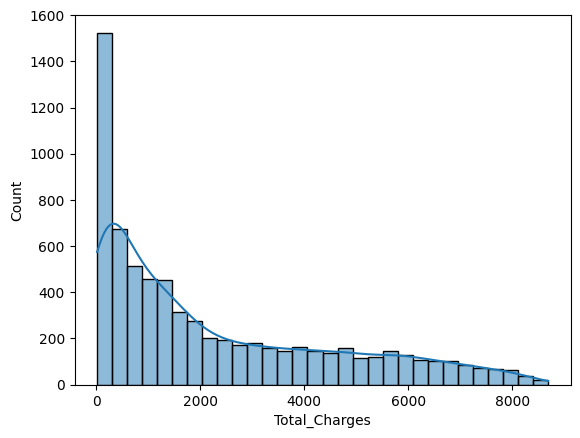

In [ ]:
# check distribution of Total charges
sns.histplot(df['Total_Charges'], bins=30, kde=True)
plt.show()

In [ ]:
# Since distribution is skewed replace with median
df.loc[:,'Total_Charges'].fillna(df.loc[:,'Total_Charges'].median(),inplace=True)

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# Exploratory data analysis

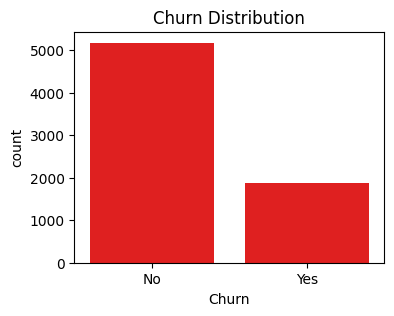

In [ ]:
plt.figure(figsize=(4,3))
sns.countplot(df, x='Churn',color='red')
plt.title("Churn Distribution")
plt.show()

Insights

Customer Retention: A large proportion of customers continue using the service, indicating relatively strong retention.

Churn Rate: A significant portion of customers have churned, which suggests areas for improvement in customer satisfaction or service quality.

Opportunity for Improvement: Reducing the churn rate could lead to better customer loyalty and more stable revenue streams.

Actionable Insight: The company could benefit from targeted efforts to understand and address the reasons behind the churn.

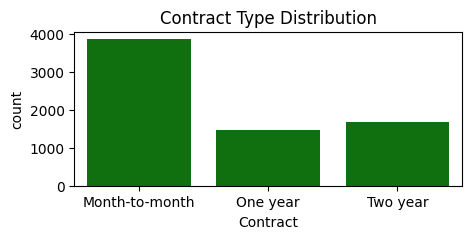

In [ ]:

plt.figure(figsize=(5,2))
sns.countplot(df, x='Contract',color='green')
plt.title("Contract Type Distribution")
plt.show()

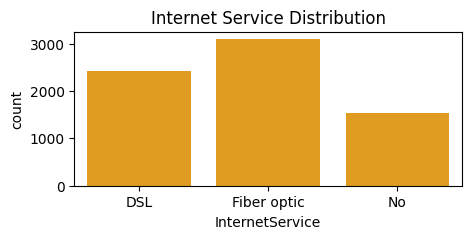

In [ ]:

plt.figure(figsize=(5,2))
sns.countplot(df, x='InternetService',color='orange')
plt.title("Internet Service Distribution")
plt.show()

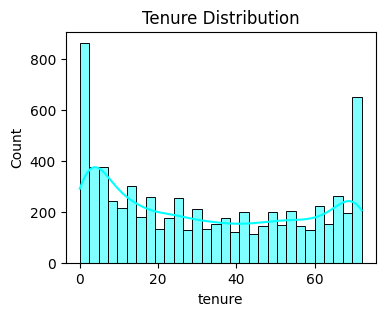

In [ ]:
#tenure – Number of months the customer has stayed with the company.
plt.figure(figsize=(4,3))
sns.histplot(df['tenure'], bins=30, kde=True,color='cyan')
plt.title("Tenure Distribution")
plt.show()



There is a sharp peak in the 0–5 months range, suggesting that many customers leave early. After the initial churn, customer retention appears more consistent, with more stable counts in the 20–60 month range.

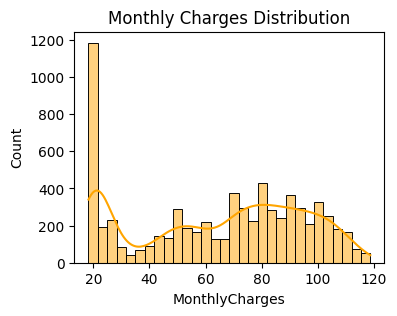

In [ ]:
plt.figure(figsize=(4,3))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True, color="orange")
plt.title("Monthly Charges Distribution")
plt.show()

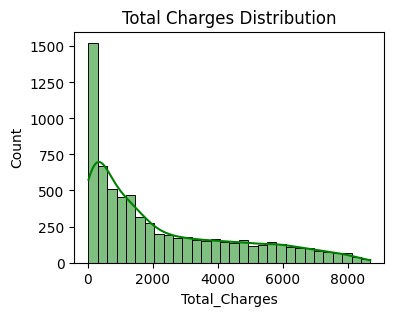

In [ ]:
plt.figure(figsize=(4,3))
sns.histplot(df['Total_Charges'], bins=30, kde=True, color="green")
plt.title("Total Charges Distribution")
plt.show()

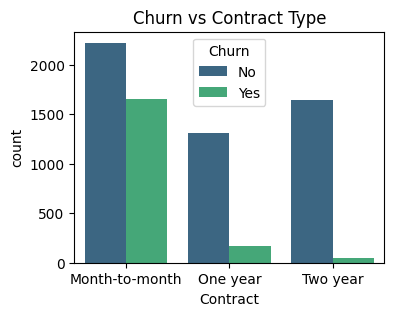

In [ ]:
#Contract – Customer’s contract type (Month-to-month/One year/Two year).
plt.figure(figsize=(4,3))
sns.countplot(df, x='Contract', hue='Churn',palette='viridis')
plt.title("Churn vs Contract Type")
plt.show()


Customers with Month-to-Month contracts have the highest churn rate, indicating that customers with flexible, short-term contracts are more likely to leave.

 Customers with One-Year and Two-Year contracts show significantly lower churn, suggesting that longer commitment contracts help in retention.

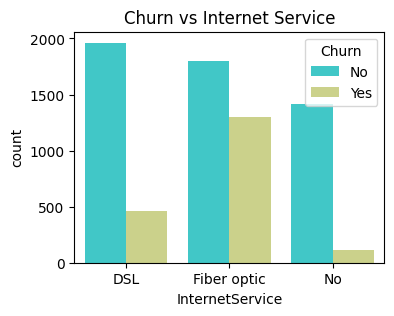

In [ ]:
plt.figure(figsize=(4,3))
sns.countplot(df, x='InternetService', hue='Churn',palette='rainbow')
plt.title("Churn vs Internet Service")
plt.show()

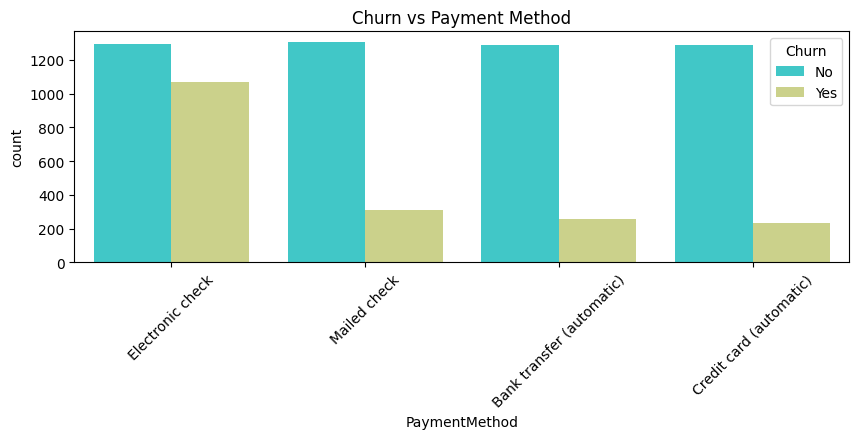

In [ ]:
plt.figure(figsize=(10,3))
sns.countplot(df, x='PaymentMethod', hue='Churn',palette='rainbow')
plt.title("Churn vs Payment Method")
plt.xticks(rotation=45)
plt.show()

Customers who use Electronic Check as a payment method have the highest churn rate.
 The company could focus on Electronic Check users by offering incentives or improving the payment process to reduce churn.

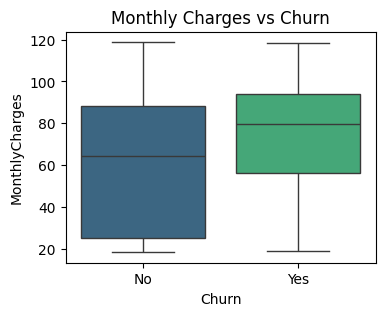

In [ ]:
plt.figure(figsize=(4,3))
sns.boxplot(df, x='Churn', y='MonthlyCharges',palette='viridis')
plt.title("Monthly Charges vs Churn")
plt.show()